In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

## Data Preparation and Exploration

In [2]:
# Load the dataset
df = pd.read_csv('exchange_rate.csv')
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [3]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
# Set date as index
df.set_index('date', inplace=True)
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [5]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ex_rate,7588.0,0.776974,0.13662,0.483297,0.701422,0.761377,0.873477,1.102536


In [6]:
# Check missing values
df.isnull().sum()

Ex_rate    0
dtype: int64

In [7]:
# Check duplicates
df.duplicated().sum()

np.int64(2258)

In [8]:
df.index.duplicated().sum()

np.int64(0)

- Although 2258 rows appear duplicated, the date index has 0 duplicates.
- This means exchange rate values repeat across different days, which is normal.
- Therefore, no rows need to be removed.

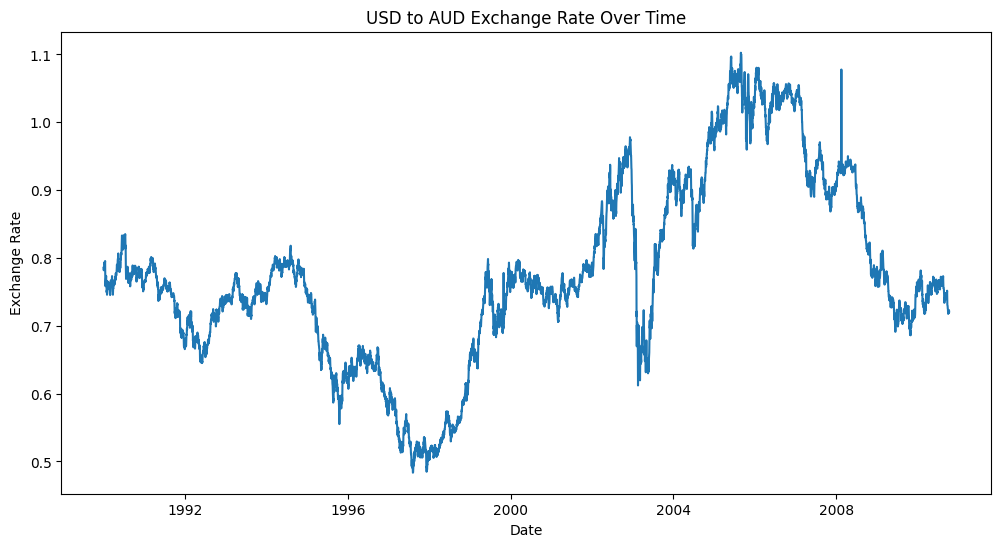

In [9]:
# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df['Ex_rate'])
plt.title("USD to AUD Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

The exchange rate fluctuates over time with several noticeable increases and decreases.

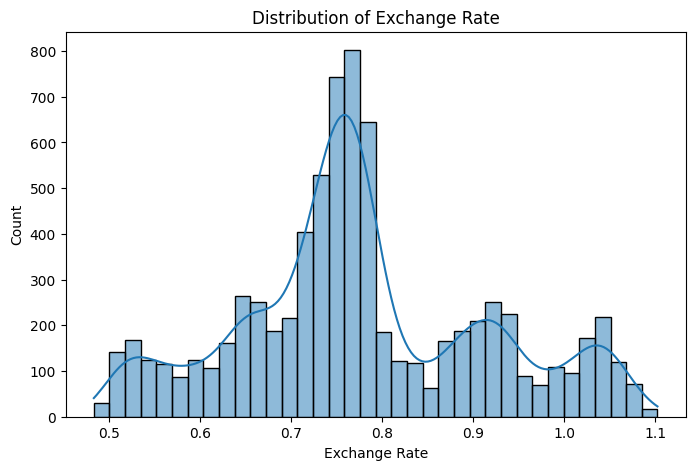

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Ex_rate'], kde=True)
plt.title("Distribution of Exchange Rate")
plt.xlabel("Exchange Rate")
plt.show()

Most exchange rate values are concentrated around the middle range, with fewer extreme values.

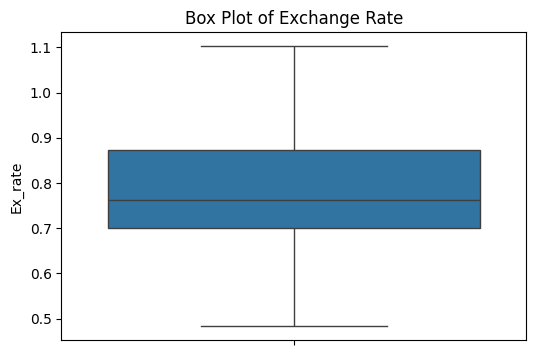

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Ex_rate'])
plt.title("Box Plot of Exchange Rate")
plt.show()

The data shows some variability and a few possible outliers in the exchange rate values.

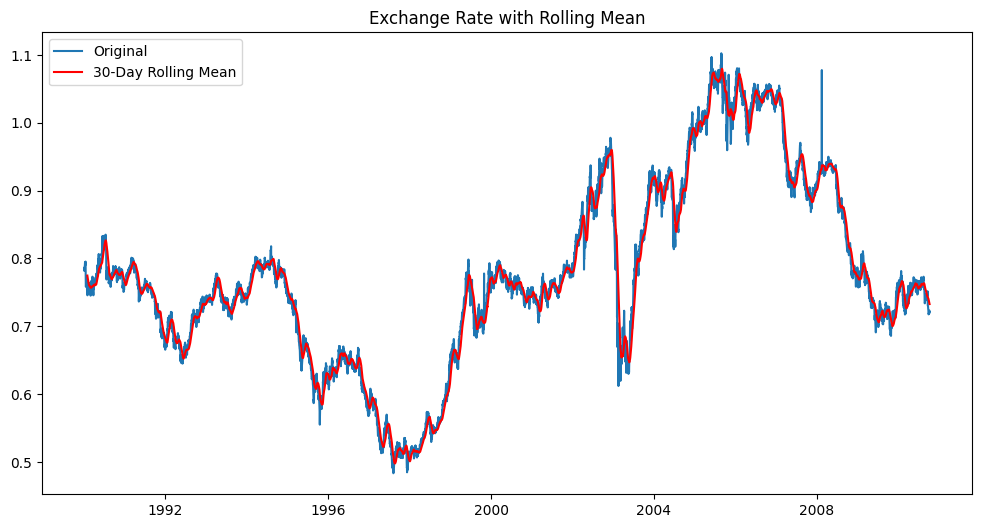

In [12]:
rolling_mean = df['Ex_rate'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Ex_rate'], label='Original')
plt.plot(rolling_mean, color='red', label='30-Day Rolling Mean')
plt.title("Exchange Rate with Rolling Mean")
plt.legend()
plt.show()

The rolling mean line smooths short-term fluctuations and highlights the overall trend of the exchange rate.

In [13]:
## Stationarity Test (ADF Test)
# Perform Augmented Dickey-Fuller Test
adf_test = adfuller(df['Ex_rate'])

print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])

if adf_test[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

ADF Statistic: -1.6649941807381368
p-value: 0.4492327353597985
The time series is non-stationary.


## Model Building - ARIMA

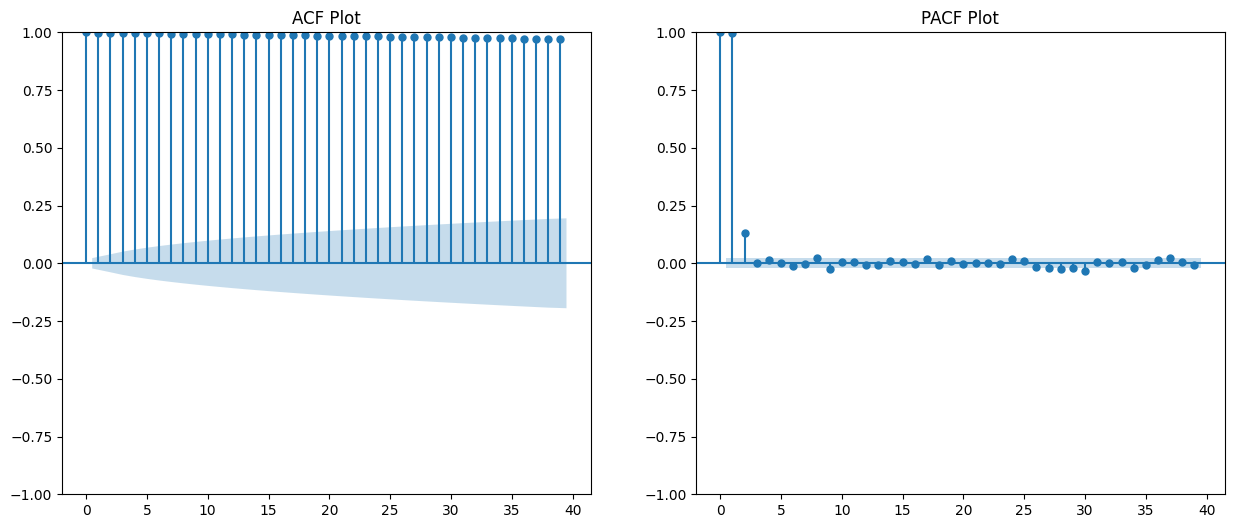

In [14]:
# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_acf(df['Ex_rate'], ax=axes[0])
axes[0].set_title("ACF Plot")

plot_pacf(df['Ex_rate'], ax=axes[1])
axes[1].set_title("PACF Plot")

plt.show()

- The ACF plot shows strong correlation across many lags, indicating the time series is not stationary.
- The PACF plot shows a significant spike at the first lag and then drops, suggesting short-term dependence in the series.

In [15]:
# Initial ARIMA parameters (p, d, q) based on ACF and PACF plots
p, d, q = 1, 1, 1
# Build the model
model = ARIMA(df['Ex_rate'], order=(p, d, q))
# Fit the model
model_fit = model.fit()
# Summary of the model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Thu, 05 Mar 2026   AIC                         -56102.322
Time:                        16:08:11   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

An ARIMA(1,1,1) model is initialized based on the patterns observed in the ACF and PACF plots."

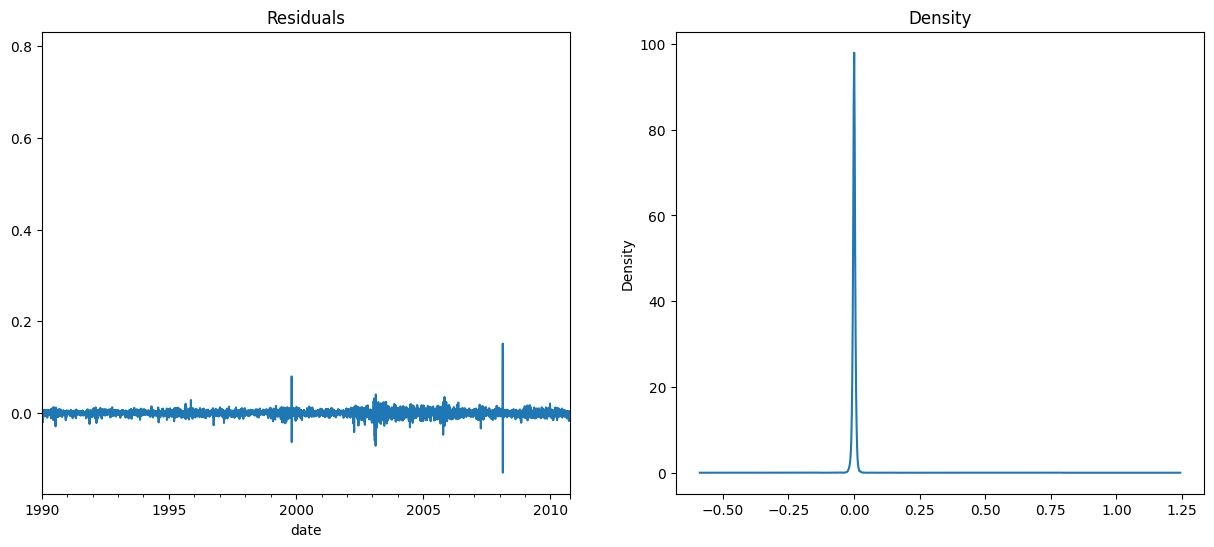

In [16]:
# Plot residuals
residuals = model_fit.resid
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
# Residual time series
residuals.plot(title="Residuals", ax=ax[0])
# Residual density plot
residuals.plot(kind='kde', title='Density', ax=ax[1])

plt.show()

- The residuals fluctuate randomly around zero with no clear pattern, indicating the model has captured most of the structure in the data.
- The residual distribution is centered around zero, suggesting that the errors are approximately normally distributed.

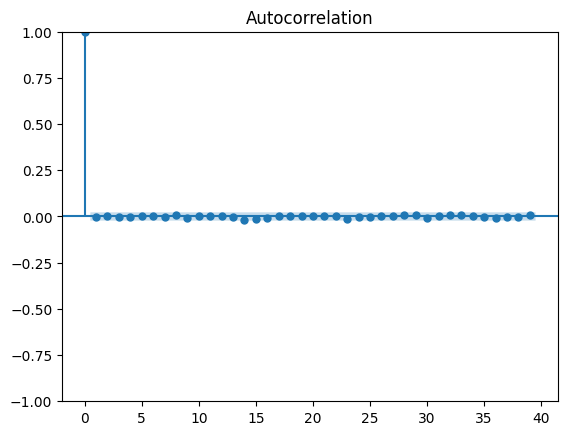

In [17]:
# Plot ACF of residuals
plot_acf(residuals)
plt.show()

The ACF plot of residuals shows no significant autocorrelation beyond lag 0, indicating that the residuals behave like white noise and the ARIMA model fits the data well.

In [18]:
# Forecast future values
forecast_steps = 12
forecast = model_fit.get_forecast(steps=forecast_steps)

forecast_values = forecast.predicted_mean
forecast_index = pd.date_range(start=df.index[-1], periods=forecast_steps+1, freq='M')[1:]

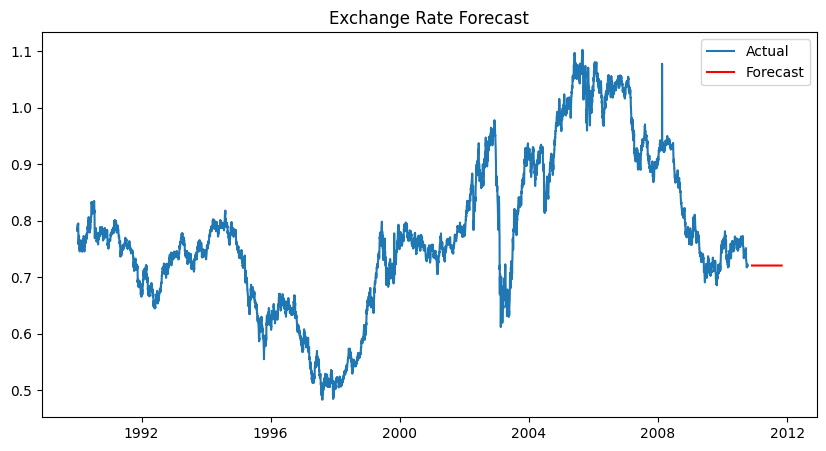

In [19]:
plt.figure(figsize=(10,5))
plt.plot(df['Ex_rate'], label='Actual')
plt.plot(forecast_index, forecast_values, color='red', label='Forecast')
plt.title("Exchange Rate Forecast")
plt.legend()
plt.show()

- The ARIMA(1,1,1) model forecasts a relatively stable exchange rate around the recent trend for the next 12 periods.

## Model Building - Exponential Smoothing

In [20]:
# Fit Holt's Linear Trend model
holt_model = ExponentialSmoothing(df['Ex_rate'], trend='add')
holt_result = holt_model.fit()

In [21]:
# Print model summary
print(holt_result.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 7588
Model:             ExponentialSmoothing   SSE                              0.273
Optimized:                         True   AIC                         -77641.010
Trend:                         Additive   BIC                         -77613.272
Seasonal:                          None   AICC                        -77640.999
Seasonal Periods:                  None   Date:                 Thu, 05 Mar 2026
Box-Cox:                          False   Time:                         16:08:12
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8698416                alpha                 True
smoothing_trend             0.0000

- The Holt Exponential Smoothing model with additive trend successfully fits the exchange rate data, emphasizing recent observations for forecasting.

In [22]:
holt_forecast = holt_result.forecast(steps=12)
holt_index = pd.date_range(start=df.index[-1], periods=13, freq='M')[1:]

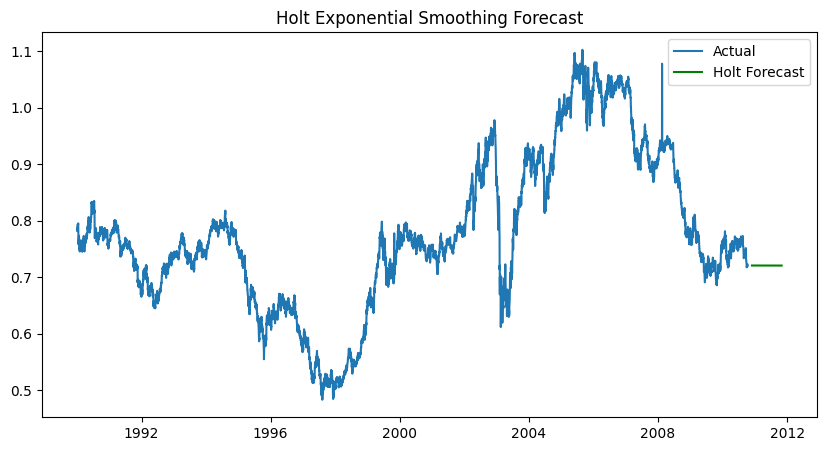

In [23]:
plt.figure(figsize=(10,5))
plt.plot(df['Ex_rate'], label='Actual')
plt.plot(holt_index, holt_forecast, label='Holt Forecast', color='green')
plt.title("Holt Exponential Smoothing Forecast")
plt.legend()
plt.show()

- The Holt Exponential Smoothing model forecasts the exchange rate for the next 12 months based on the historical trend.
- The forecast line appears almost flat, indicating that the model detects very little trend in the future values.
- This suggests the exchange rate is expected to remain relatively stable in the short-term forecast period.

## Evaluation and Comparison

In [24]:
# Compute error metrics for ARIMA
arima_forecast_values = forecast_values[:forecast_steps]

arima_mae = mean_absolute_error(df['Ex_rate'][-forecast_steps:], arima_forecast_values)
arima_rmse = np.sqrt(mean_squared_error(df['Ex_rate'][-forecast_steps:], arima_forecast_values))
arima_mape = np.mean(np.abs((df['Ex_rate'][-forecast_steps:] - arima_forecast_values) / df['Ex_rate'][-forecast_steps:])) * 100

In [25]:
print("ARIMA Model Performance:")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

ARIMA Model Performance:
MAE: 0.0016644924340379526
RMSE: 0.002000358073451703
MAPE: nan


In [26]:
# Holt Forecast values
holt_forecast_values = holt_forecast[:forecast_steps]

holt_mae = mean_absolute_error(df['Ex_rate'][-forecast_steps:], holt_forecast_values)
holt_rmse = np.sqrt(mean_squared_error(df['Ex_rate'][-forecast_steps:], holt_forecast_values))
holt_mape = np.mean(np.abs((df['Ex_rate'][-forecast_steps:] - holt_forecast_values) / df['Ex_rate'][-forecast_steps:])) * 100

In [27]:
print("\nHolt Model Performance:")
print("MAE:", holt_mae)
print("RMSE:", holt_rmse)
print("MAPE:", holt_mape)


Holt Model Performance:
MAE: 0.001672516608442698
RMSE: 0.0019973219311007527
MAPE: nan


In [28]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Holt'],
    'MAE': [arima_mae, holt_mae],
    'RMSE': [arima_rmse, holt_rmse],
    'MAPE': [arima_mape, holt_mape]
})

print(comparison)

   Model       MAE      RMSE  MAPE
0  ARIMA  0.001664  0.002000   NaN
1   Holt  0.001673  0.001997   NaN


- The model with lower MAE, RMSE, and MAPE provides better forecasting performance.
- Based on the evaluation metrics, the model with smaller error values is considered more accurate for predicting the exchange rate.

### Model Comparison and Discussion

- The ARIMA and Holt’s Linear Trend models were evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

- The ARIMA model produced an MAE of 0.001664 and an RMSE of 0.002000, while the Holt model produced an MAE of 0.001673 and an RMSE of 0.001997. The error values for both models are very close, indicating that both models perform similarly on the exchange rate dataset.

- However, the ARIMA model slightly outperforms Holt’s model in terms of MAE, suggesting marginally better prediction accuracy. On the other hand, Holt’s model shows a slightly lower RMSE, indicating similar forecasting capability.

- Overall, both models provide reasonable forecasts, but ARIMA is generally more suitable for time series data because it captures autocorrelation and underlying patterns more effectively, while Holt’s model mainly focuses on trend components.

### Conclusion

In this analysis, we studied the USD to AUD exchange rate dataset using time series techniques.

1. First, we performed exploratory data analysis to understand the trend and distribution of the exchange rate.
2.  Then we applied the ARIMA model to capture the autocorrelation patterns in the data and forecast future values.
3.  After that, Holt’s Linear Trend model was used to forecast the data based on the trend component.
4.  The performance of both models was evaluated using error metrics such as MAE and RMSE.
5.  From the results, both models performed similarly, but ARIMA showed slightly better forecasting accuracy for this dataset.